#### 1- Préparation

In [42]:
# Chargement des librairies
import pandas as pd

In [43]:
# Chargement des données
data = pd.read_csv('data/dataset_malware.csv')

#### 2- Exploration des données - Exploratory Data Analysis (EDA)
Ici, on se pose des questions sur le jeu de données.

In [44]:
# Combiend a-t-on de lignes et de colonnes au total ?
data.shape

(19611, 79)

In [45]:
# à quoi ressemble le jeu de données ?
data.head()

,Name,e_magic,e_cblp,e_cp,e_crlc,e_cparhdr,e_minalloc,e_maxalloc,e_ss,e_sp,...,SectionMaxChar,SectionMainChar,DirectoryEntryImport,DirectoryEntryImportSize,DirectoryEntryExport,ImageDirectoryEntryExport,ImageDirectoryEntryImport,ImageDirectoryEntryResource,ImageDirectoryEntryException,ImageDirectoryEntrySecurity
0,VirusShare_a878ba26000edaac5c98eff4432723b3,23117,144,3,0,4,0,65535,0,184,...,3758096608,0,7,152,0,0,54440,77824,73728,0
1,VirusShare_ef9130570fddc174b312b2047f5f4cf0,23117,144,3,0,4,0,65535,0,184,...,3791650880,0,16,311,0,0,262276,294912,0,346112
2,VirusShare_ef84cdeba22be72a69b198213dada81a,23117,144,3,0,4,0,65535,0,184,...,3221225536,0,6,176,0,0,36864,40960,0,0
3,VirusShare_6bf3608e60ebc16cbcff6ed5467d469e,23117,144,3,0,4,0,65535,0,184,...,3224371328,0,8,155,0,0,356352,1003520,0,14109472
4,VirusShare_2cc94d952b2efb13c7d6bbe0dd59d3fb,23117,144,3,0,4,0,65535,0,184,...,3227516992,0,2,43,0,0,61440,73728,0,90624


In [46]:
# Quels sont les noms des colonnes ?
data.columns.sort_values()

Index(['AddressOfEntryPoint', 'BaseOfCode', 'Characteristics', 'CheckSum',
       'DirectoryEntryExport', 'DirectoryEntryImport',
       'DirectoryEntryImportSize', 'DllCharacteristics', 'FileAlignment',
       'ImageBase', 'ImageDirectoryEntryException',
       'ImageDirectoryEntryExport', 'ImageDirectoryEntryImport',
       'ImageDirectoryEntryResource', 'ImageDirectoryEntrySecurity',
       'LoaderFlags', 'Machine', 'Magic', 'MajorImageVersion',
       'MajorLinkerVersion', 'MajorOperatingSystemVersion',
       'MajorSubsystemVersion', 'Malware', 'MinorImageVersion',
       'MinorLinkerVersion', 'MinorOperatingSystemVersion',
       'MinorSubsystemVersion', 'Name', 'NumberOfRvaAndSizes',
       'NumberOfSections', 'NumberOfSymbols', 'PointerToSymbolTable',
       'SectionAlignment', 'SectionMainChar', 'SectionMaxChar',
       'SectionMaxEntropy', 'SectionMaxPhysical', 'SectionMaxPointerData',
       'SectionMaxRawsize', 'SectionMaxVirtual', 'SectionMaxVirtualsize',
       'SectionMi

In [ ]:
# Combien de valeurs manquantes dans le jeu de données ?
data.isna().sum() # par colonne
data.isna().sum().sum() # Au total

0

In [48]:
# Combien de valeurs uniques a la colonne cible ?
data.Malware.unique()

array([1, 0])

<Axes: title={'center': 'Distribution de la variable cible'}, xlabel='Malware', ylabel='Count'>

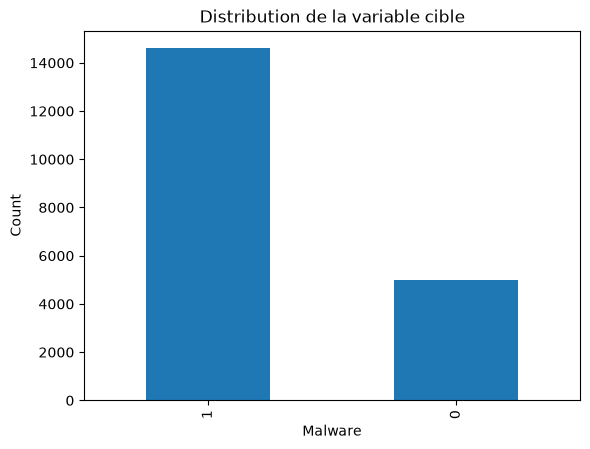

In [49]:
data.Malware.value_counts().plot(kind='bar', title='Distribution de la variable cible', xlabel='Malware', ylabel='Count')

#### 3- Préparation des données - Data preprocessing

In [50]:
# A-t-on des colonnes non numériques dans le jeu de données ?
data.dtypes.value_counts()

int64      77
object      1
float64     1
Name: count, dtype: int64

In [51]:
data.select_dtypes(include=['object'])

,Name
0,VirusShare_a878ba26000edaac5c98eff4432723b3
1,VirusShare_ef9130570fddc174b312b2047f5f4cf0
2,VirusShare_ef84cdeba22be72a69b198213dada81a
3,VirusShare_6bf3608e60ebc16cbcff6ed5467d469e
4,VirusShare_2cc94d952b2efb13c7d6bbe0dd59d3fb
...,...
19606,clip.exe
19607,VNC-Server-6.2.0-Windows.exe
19608,Microsoft.GroupPolicy.Management.ni.dll
19609,cryptuiwizard.dll


In [52]:
data.drop(['Name'], axis=1, inplace=True)

In [53]:
# base method : label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for column in data:
    data[column] = le.fit_transform(data[column])

In [54]:
features = data.drop(['Malware'], axis=1)
labels = data['Malware']

In [55]:
from sklearn.model_selection import train_test_split
train_features,test_features,train_labels,test_labels = train_test_split(features,labels,test_size = 0.2)


#### 3- Data processing

In [56]:
# Model Training
from sklearn.neighbors import KNeighborsClassifier

classifier = KNeighborsClassifier(n_neighbors=5)
classifier = classifier.fit(train_features, train_labels)

In [57]:
predicted_labels = classifier.predict(test_features)
predicted_labels

array([0, 1, 1, ..., 1, 0, 1])

In [58]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(test_labels, predicted_labels)
accuracy

0.9727249553912822

In [59]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_labels, predicted_labels)
cm

array([[ 962,   80],
       [  27, 2854]])

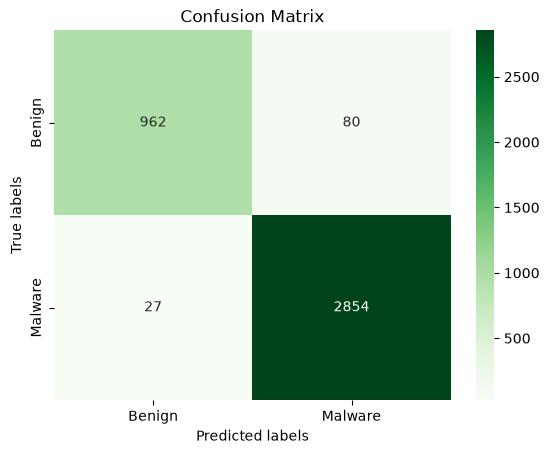

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = plt.subplot()
sns.heatmap(cm, annot=True, ax = ax, fmt='g', cmap='Greens'); #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels');
ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix'); 
ax.xaxis.set_ticklabels(['Benign', 'Malware']); 
ax.yaxis.set_ticklabels(['Benign', 'Malware']);

# Verdict : 
Taille de jeu de données : 6.7 Mo en format csv.

Modèle : KNN avec K = 5

Accuracy : 96.78817231710426%
Besoin : 77 colonnes.

Temps d'exécution : 27 secondes pour 19611 prédictions, soit 1.3767783 millisecondes par prédiction.

Pouvoir explicatif : fort nativement. Un fichier est classifié comme virus si les 5 plus proches lignes sont majoritairement des virus (min. 3 sur 5).



# À faire : 
1. Exécutez le même code. Avez-vous eu le même résultats que moi? Accuracy ou temps d'exécution.

2. Si vous changez K, pouvez-vous faire mieux? Accuracy ou temps d'exécution.

3. Si vous changez KNN avec un autre modèle, pouvez-vous faire mieux? Accuracy ou temps d'exécution.
    - Pour vous aider, voici d'autres modèles possibles :
        - from sklearn.linear_model import LogisticRegression
        - from sklearn.tree import DecisionTreeClassifier
        - from sklearn.ensemble import RandomForestClassifier
        - from sklearn.svm import SVC
        - from sklearn.naive_bayes import GaussianNB
    - La liste complète est sur le site de scikit-learn : https://scikit-learn.org/stable/supervised_learning.html